# Deep Learning of Representations: Looking Forward — Summary

# https://arxiv.org/pdf/1305.0445

## Abstract
This paper by Yoshua Bengio (2013) is a forward-looking position paper that surveys the state of deep learning research and identifies four major open challenges: scaling computations to larger models and datasets, reducing optimization difficulties from ill-conditioning and local minima, designing efficient inference and sampling procedures, and learning representations that disentangle the underlying factors of variation in data. For each challenge, the paper reviews existing approaches and proposes forward-looking research directions.

## Problems
- **Scaling**: Current training algorithms (e.g., SGD) are inherently sequential and difficult to parallelize, while datasets and desired model capacities are growing faster than a single machine can handle; larger models appear to require worse-than-linear increases in computation.
- **Optimization**: It is unclear whether training difficulties in deep and recurrent networks stem primarily from local minima or from ill-conditioning of the Hessian matrix; larger networks show diminishing "return on investment" per added hidden unit under fixed training iterations.
- **Inference and Sampling**: Most graphical models used in deep learning (except RBMs) require expensive, iterative inference (MAP, MCMC, variational) that slows training; posteriors over latent variables can be highly multi-modal, and MCMC methods suffer from slow mixing between modes, especially as models improve and their distributions sharpen.
- **Disentangling**: Machine learning performance is heavily dependent on data representation, but current algorithms only partially succeed at separating the independent explanatory factors underlying observed data, limiting generalization and transfer to new tasks.

## Proposed Solutions
- **Scaling**: Asynchronous SGD across multiple nodes with lock-free parameter sharing; sparse parameter updates (exploiting gradient sparsity from dropout, maxout, stochastic pooling); and *conditional computation*, where learned, distributed gating units dynamically activate only relevant subsets of hidden units per example, analogous to decision trees but preserving distributed representations.
- **Optimization**: Encouraging sparse gradients to make the Hessian more diagonal (reducing ill-conditioning); rectifier and maxout non-linearities; centering/normalizing inputs and hidden units; noise injection (dropout, denoising) for faster symmetry-breaking; gradient-flow-preserving techniques (gradient clipping, penalties encouraging propagated gradients to maintain magnitude) for recurrent networks; curriculum learning and intermediate-concept guidance for tasks requiring compositional abstraction.
- **Inference and Sampling**: Tempering/simulated-annealing-inspired MCMC to improve mode mixing; exploiting the empirical finding that mixing is easier at higher (more abstract) representation levels; learned approximate inference (as in predictive sparse coding, wake-sleep); and a proposed radical alternative—*avoiding explicit latent-variable inference altogether* by directly learning parametrized computational graphs (e.g., generalized denoising auto-encoders, Generative Stochastic Networks) that implicitly estimate the data distribution via backpropagation-trained reconstruction objectives.
- **Disentangling**: A list of generic priors to guide representation learning toward disentangled factors, including smoothness, multiple explanatory factors, hierarchical organization, semi-supervised learning, shared factors across tasks, manifold structure, natural clustering, temporal/spatial coherence, sparsity, and simplicity of factor dependencies.

## Purpose
The paper aims to consolidate the major open research challenges in deep learning as of 2013 and articulate concrete, actionable research directions to guide the community toward more scalable, better-optimized, more efficient, and more semantically meaningful (disentangled) representation learning systems, ultimately in service of progress toward artificial intelligence.

## Methodology
As a position/perspective paper, the methodology is a structured literature synthesis and conceptual argumentation rather than novel experimentation:
- **Background review**: Surveys supervised deep nets, convolutional architectures, dropout, layer-wise pre-training (unsupervised and supervised), directed/undirected graphical models with anonymous latent variables (RBMs, DBNs, DBMs), regularized auto-encoders (denoising, contractive), and sparse coding/PSD.
- **Challenge-by-challenge analysis**: Each of the four challenge areas (Sections 3–6) is treated with a "Challenge" subsection framing the problem and a "Solution Paths" subsection proposing or reviewing candidate approaches.
- **Theoretical grounding**: Draws on Hessian condition-number analysis for optimization difficulty, the manifold hypothesis for explaining slow MCMC mixing, and score-matching theory (Alain and Bengio, 2013) for the probabilistic interpretation of auto-encoder reconstruction error, expressed as $$\frac{\partial \log p(x)}{\partial x}$$.
- **Illustrative quantitative example**: Uses a toy combinatorial calculation to argue that realistic latent-variable posteriors can have on the order of $$10^{33}$$ plausible modes, motivating the impracticality of exhaustive summation in inference.

## Results
As a perspective paper, "results" consist of synthesized findings and hypotheses drawn from cited empirical work rather than the authors' own new experiments:
- Rectifying non-linearities and proper initialization (Glorot and Bengio, 2010) enable training of deep supervised nets without unsupervised pre-training, especially with large labeled datasets, yielding 30–50% error reductions on speech and object recognition benchmarks (e.g., ImageNet top-5 error reduced from 26.1% to 15.3% by Krizhevsky et al., 2012).
- Dauphin and Bengio (2013) show diminishing "return on investment" as network size grows under fixed training iterations, implicating increased Hessian ill-conditioning.
- Gulcehre and Bengio (2013) demonstrate tasks requiring compositional, multi-level abstraction on which all tested black-box deep learning methods fail, but which become solvable when intermediate sub-tasks are pre-trained—evidence that current optimization/representation methods do not automatically discover necessary abstractions.
- Bengio et al. (2013b) report that MCMC mixing between modes is empirically easier at higher (deeper) levels of learned representations, supporting the hypothesis that deeper representations are more disentangled and higher-entropy.
- Sparse convolutional RBMs and sparse denoising auto-encoders show hidden units that specialize to individual factors of variation (e.g., topic vs. sentiment in text), evidencing partial disentangling, though never perfect.

## Conclusions
The paper concludes that despite substantial empirical and theoretical progress since deep learning's 2006 resurgence, four interconnected challenges—computational scaling, optimization difficulty, expensive/inadequate inference and sampling, and imperfect disentangling of explanatory factors—remain central obstacles to advancing representation learning toward AI-level competence. It argues that disentangling is the most ambitious and potentially highest-impact challenge, since well-disentangled representations would substantially ease the other three problems (enabling sparse updates, reducing ill-conditioning, and simplifying inference). The paper closes by advocating a departure from strict probabilistic latent-variable formalism toward directly learned computational graphs (e.g., Generative Stochastic Networks) as a promising unifying direction for future research.

# Mathematical and Statistical Content Summary

## 1. Auto-Encoder Reconstruction Error
$$\|r(x) - x\|^2$$
The squared difference between an auto-encoder's reconstruction $r(x)$ and the original input $x$. This is the basic training objective for auto-encoders: minimizing this error at training points while keeping it high elsewhere prevents the model from learning the trivial identity function and forces it to capture structure in the data.

## 2. Reconstruction Function Decomposition
$$r(x) = g(f(x))$$
Decomposes reconstruction into an encoding function $f(\cdot)$ (mapping input to a hidden representation) followed by a decoding function $g(\cdot)$ (mapping the representation back to input space). This formalizes the encoder–decoder structure common to all auto-encoder variants discussed in the paper.

## 3. Denoising Auto-Encoder Objective
$$\|r(N(x)) - x\|^2$$
Instead of reconstructing the clean input, the denoising auto-encoder reconstructs the original $x$ from a corrupted version $N(x)$. This forces the model to learn robust structure rather than merely copying the input, and is shown to implicitly estimate the data density.

## 4. Contractive Auto-Encoder Penalty
$$\left\|\frac{\partial f(x)}{\partial x}\right\|_F^2$$
The squared Frobenius norm of the encoder's Jacobian, added to the reconstruction loss. It penalizes sensitivity of the hidden representation $f(x)$ to small changes in $x$, encouraging the encoder to be locally "flat" (contractive) except in directions needed to distinguish nearby training examples—these directions correspond to the data manifold.

## 5. Score Function and Its Estimation
$$\frac{\partial \log p(x)}{\partial x}$$
The "score" is the gradient of the log-density with respect to the input (not parameters, unlike the usual statistical definition). A key theoretical result cited in the paper is that the reconstruction error vector (reconstruction minus input) of denoising/contractive auto-encoders is an estimator of this score. Since the score is small both at density peaks (modes) and troughs (minima or saddle points), reconstruction error alone cannot be used directly as an energy function (which should only be low near high-probability regions).

## 6. Energy-Based Probability Definition
Probability is defined as the normalized exponential of negative energy (implicit form referenced in the paper):
$$P(x) \propto \exp(-\text{Energy}(x))$$
This underlies energy-based models (RBMs, Boltzmann machines) and clarifies why reconstruction error is not automatically a valid energy function, since energy should be low only at high-probability points, whereas score-based reconstruction error is small at both maxima and minima of density.

## 7. Marginalization Over Latent Variables for Prediction
$$P(y \mid x) = \sum_h P(y \mid h) P(h \mid x)$$
To make an optimal prediction $y$ given observed $x$ while using a latent-variable model, one must sum (marginalize) over all possible latent configurations $h$, weighted by the posterior $P(h\mid x)$. The paper uses this formula to argue that when the posterior is highly multi-modal, this sum becomes computationally intractable.

## 8. Combinatorial Estimate of Posterior Modes
$$1\% \times (2^5 \times 100)^{10} \approx 10^{33}$$
A worked numerical example: for a scene with 10 objects, each having 5 ambiguous binary attributes (out of 20) and 100 plausible categorical identities, only about 1% of configurations are jointly plausible. This yields roughly $10^{33}$ plausible latent configurations (down from a naive upper bound of $(2^{20}\times 10000)^{10}\approx 10^{100}$). This calculation is used purely illustratively, to argue that exact summation over latent-variable posteriors is computationally infeasible for realistic AI-scale problems, motivating the paper's proposal to avoid explicit latent-variable inference.

## 9. Approximate Posterior via Learned Parametrization
$$Q_{\theta=f(x)}(h) \approx P(h \mid x)$$
Represents an approximate posterior distribution $Q$ whose parameters $\theta$ are computed by a learned function $f(x)$ of the input. This is the mathematical basis for "conditional RBMs" and other learned approximate inference schemes, allowing rich, potentially multi-modal approximations (e.g., an RBM) instead of simple unimodal or factorized posteriors.

## 10. Direct Prediction Bypassing Latent Variables
$$P(y \mid x) \approx g(f(x)) \equiv \pi(x) = g(f(x))$$
The paper's proposed alternative to explicit inference: rather than computing $f(x)$ (approximate posterior parameters) and then separately marginalizing/decoding via $g$, directly learn a single function $\pi(x)$ that estimates $P(y\mid x)$. This collapses the traditional two-stage inference-then-decision pipeline into direct discriminative learning, avoiding the intractable sum in item 7.

## 11. Hessian Matrix and Condition Number
$$\frac{\partial^2 C}{\partial \theta_i \partial \theta_j} = \frac{\partial}{\partial \theta_j}\frac{\partial C}{\partial \theta_i}$$
The Hessian's off-diagonal entries capture how changing one parameter $\theta_j$ affects the gradient with respect to another parameter $\theta_i$ — information that plain (first-order) gradient descent ignores. The paper explains that in a quadratic loss "bowl," training time scales with the **condition number** of the Hessian (ratio of largest to smallest eigenvalue): a large condition number (ill-conditioning) causes slow convergence. This motivates the paper's hypothesis that sparse gradients — many zero entries — effectively zero out many off-diagonal Hessian terms, making the matrix more diagonal and thus easier to optimize.

## 12. Gradient Clipping
$$\text{if } \|g\| > \tau: \quad g \leftarrow \tau \frac{g}{\|g\|}$$
(paraphrased from the paper's footnote: "when the norm of the gradient is above a threshold $\tau$, reduce it to $\tau$")
A heuristic to prevent exploding gradients in recurrent networks: when the gradient vector's norm exceeds a threshold $\tau$, it is rescaled down to that threshold while preserving direction. Combined with penalties that encourage gradients to maintain magnitude over long sequences, this addresses the vanishing/exploding gradient problem in deep and recurrent architectures.

## 13. Spectral Radius Condition for Gradient Propagation
Implicit reference: the Jacobian product across layers/time steps should have a **spectral radius (largest eigenvalue) close to 1**. Since composing many non-linear layers corresponds to multiplying many Jacobian matrices, keeping this spectral radius near 1 (as in Echo State Network initialization or LSTM's constant error carousel) prevents gradients from vanishing (radius $\ll 1$) or exploding (radius $\gg 1$) as they propagate backward through depth or time.

## 14. Directed Graphical Model for PCA / ICA / Sparse Coding
$$x = Wh + \text{noise}$$
A shared generative model underlying PCA, ICA, and sparse coding: observed data $x$ is generated by linearly combining latent factors $h$ (via weight matrix $W$) plus noise. These methods differ only in the prior placed on $h$ (e.g., Gaussian for PCA/ICA-like models, Laplace for sparse coding, which encourages many zero entries in the inferred $h$).

## 15. Mutual Information and Representation Entropy (Conceptual)
The paper notes that maximizing mutual information between inputs and their learned deterministic representation (which is approximately what auto-encoders do) is equivalent to maximizing the entropy of the learned representation. This is used to support the hypothesis that deeper/auto-encoder-based representations become more "spread out" (higher entropy, more uniform), which in turn explains why MCMC mixing between modes is empirically easier at higher representation levels.

## Summary of Role in the Paper
The mathematical content in this paper serves three main purposes:
1. **Characterizing model objectives** (items 1–4, 14) — defining the loss functions and regularization penalties used across auto-encoder variants and classical latent-variable models.
2. **Diagnosing training and inference difficulty** (items 5–13, 15) — using score theory, Hessian conditioning, combinatorial mode-counting, and spectral analysis to explain *why* optimization and inference are hard in deep architectures, and what properties (sparsity, spectral radius near 1, bounded gradient norm) mitigate these difficulties.
3. **Motivating the paper's proposed research direction** (items 7–10) — the marginalization formula and combinatorial explosion example are used specifically to argue for abandoning explicit latent-variable inference in favor of directly learned predictive functions, which is the paper's most novel forward-looking proposal.

# Key Problems, Limitations, and Proposed Solutions

| # | Problem / Research Gap | How This Limits Prior Work | Proposed Solution in the Paper |
|---|------------------------|------------------------------|----------------------------------|
| 1 | Training algorithms for deep learning (e.g., stochastic gradient descent) are inherently sequential — each parameter update depends on completion of the previous one. | Prevents trivial parallelization across compute nodes even as available parallel hardware (GPUs, multicore machines, clusters) continues to grow, creating a mismatch between algorithm design and available computational infrastructure. | Proposes asynchronous SGD, in which multiple model replicas train in parallel on different data subsets with a lock-free, asynchronous parameter-sharing mechanism, avoiding the inefficiency of synchronous waiting for the slowest node. |
| 2 | Datasets have grown so large that they no longer fit on a single disk or file server, making sequential full-data scanning by one CPU core impractical. | Standard sequential training procedures cannot exploit or even access all available data, limiting the amount of information a model can learn from. | Discusses distributed training approaches (e.g., Google Brain's large-scale parallelization) and highlights the need for algorithms that do not require centralized sequential data access. |
| 3 | Communication overhead between nodes is the primary bottleneck in large-scale distributed training, and current asynchronous implementations remain inefficient at thousands-of-nodes scale. | Limits the practical speed-up achievable from adding more parallel compute resources, since most of the potential gain is lost to inter-node communication cost. | Proposes sparse updates — architectures and gradient-sparsifying methods (dropout, maxout, stochastic pooling, and attending only to the largest gradient elements) so that only a small fraction of parameters need to be exchanged per update. |
| 4 | Most machine learning predictors (unlike decision trees) scale computation linearly with model size, since all parameters are touched for every example. | Prevents models from growing to the very large capacities believed necessary for AI-level tasks, since computational cost becomes prohibitive as models scale. | Introduces conditional computation: learned, distributed gating units that multiplicatively turn off computation for hidden units not relevant to a given example, achieving decision-tree-like sub-linear scaling while preserving the advantages of distributed representations. |
| 5 | It is unclear whether the primary source of deep network training difficulty is local minima or Hessian ill-conditioning, and larger networks show diminishing "return on investment" per added hidden unit under fixed training iterations. | Without knowing the dominant cause of optimization difficulty, it is unclear which class of remedies (better initialization, second-order methods, architecture changes) will be most effective, and evidence suggests naively scaling network size yields worse-than-linear returns. | Hypothesizes that sparse gradients reduce ill-conditioning by zeroing out off-diagonal Hessian terms; recommends rectifier/maxout non-linearities, input/hidden-unit centering, and further study of the return-on-investment metric to diagnose scaling behavior. |
| 6 | Certain simple-seeming tasks requiring composition of multiple levels of abstraction (e.g., detecting objects then reasoning over their categories) cause all tested black-box deep learning methods — including pre-trained ones — to fail. | Demonstrates that standard optimization and pre-training procedures do not reliably discover the compositional, multi-level abstractions needed for some AI-relevant tasks, even with unsupervised pre-training. | Proposes curriculum learning and intermediate-concept guidance — explicitly pre-training sub-tasks (e.g., single-object detection) before the full composed task — analogous to how the paper speculates human culture and language may mitigate similar optimization difficulty. |
| 7 | Vanishing and exploding gradients in recurrent and deep networks arise because long compositions of non-linear transformations correspond to products of many Jacobian matrices, which can shrink or blow up the error signal. | Limits the ability to train recurrent networks (and very deep feedforward networks) on tasks requiring long-range dependencies, since gradient information from distant time steps or layers is lost or destabilized. | Recommends initialization schemes keeping the Jacobian spectral radius near 1 (as in Echo State Networks, LSTM), training penalties that encourage propagated gradients to maintain magnitude, and gradient clipping to bound gradient norms above a threshold. |
| 8 | All graphical models used in deep learning except RBMs require iterative, computationally expensive inference (MAP, MCMC, or variational) to estimate latent variable values, slowing down training since inference is typically in the inner loop of learning. | Restricts the scalability and speed of training deep probabilistic models, especially deep Boltzmann machines and other models with intractable exact inference. | Reviews learned approximate inference approaches (predictive sparse coding, wake-sleep algorithm) that amortize inference cost by learning a fast parametric encoder jointly with the generative model. |
| 9 | Posteriors over latent variables in realistic, ambiguous data (e.g., complex visual scenes) can be highly multi-modal, with a combinatorially large number of plausible configurations (illustrated as approximately $10^{33}$ modes in a toy example), making unimodal (MAP) or factorized (mean-field) approximations inadequate. | Standard inference approximations systematically fail on tasks with genuine structured ambiguity, since assuming a single mode or independent factors discards the correlated uncertainty that is essential to correct prediction. | Proposes learning a rich, parametric multi-modal approximate posterior (e.g., a conditional RBM whose parameters are a function of the input) as an intermediate step, and ultimately proposes bypassing explicit latent-variable representation altogether by directly learning the target conditional distribution $P(y\mid x)$ via a trained computational graph. |
| 10 | MCMC methods used for sampling from deep generative models suffer from slow mixing between modes, particularly once the model has learned a sharp, peaky distribution close to the true data distribution. | As training progresses and the model improves, MCMC-based sampling and negative-phase training (e.g., in deep Boltzmann machines) become increasingly slow and unreliable, limiting the effectiveness of maximum-likelihood-style training for these models. | Reviews tempering/simulated-annealing-inspired MCMC methods, and highlights the empirical observation that mixing is easier at higher (more abstract) levels of a trained hierarchy, proposing to exploit deeper, more disentangled representations to improve mixing at lower levels. |
| 11 | Current unsupervised representation-learning algorithms only partially disentangle the true underlying explanatory factors of variation in data, and this disentanglement is never perfect. | Entangled representations make downstream supervised learning, transfer learning, and multi-task learning harder, since useful factors for a new task remain mixed together with irrelevant variation, and this incomplete disentangling is demonstrated to cause outright failure on certain compositional tasks even with unsupervised pre-training. | Proposes a set of generic priors (smoothness, multiple explanatory factors, hierarchical organization, semi-supervised sharing, shared factors across tasks, manifold structure, natural clustering, temporal/spatial coherence, sparsity, and simplicity of factor dependencies) to guide representation learning algorithms toward better disentangling, and identifies deeper representations and sparse coding-style architectures as promising empirical directions. |

In [1]:
# ============================================================================
# EDUCATIONAL REPLICATION
# Paper: "Deep Learning of Representations: Looking Forward" (Yoshua Bengio, 2013)
#
# This is a position/survey paper, not a single architecture paper. We
# therefore build a small educational model that concretely demonstrates
# its most testable, implementable ideas:
#
#   1. Denoising Auto-Encoder pre-training (Section 2.4): the encoder learns
#      to reconstruct a CLEAN image from a NOISE-CORRUPTED version of it,
#      forcing it to capture robust structure rather than the identity map.
#   2. Rectifier (ReLU) non-linearities instead of sigmoid/tanh (Section 2.1),
#      which the paper credits with enabling easier training of deep nets.
#   3. Dropout (Section 2.1) as a noise-injection regularizer that also
#      encourages sparser, more "disentangled" hidden activations.
#   4. Joint supervised + unsupervised training (Section 2, "Quick Overview"):
#      "Supervised and unsupervised objectives can be combined (simply
#      added, with a hyper-parameter as coefficient)" -- exactly as in
#      Larochelle & Bengio's discriminative RBM. We combine a classification
#      cross-entropy loss with a denoising-reconstruction loss into one
#      TOTAL loss.
#   5. A crude "disentangling" diagnostic (Section 6): per-class accuracy
#      tracked across epochs, since a well-disentangled representation
#      should make classes progressively easier to separate.
#
# TOTAL LOSS = CROSS_ENTROPY(classification) + gamma * MSE(denoising reconstruction)
# ============================================================================

import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision.transforms as T

from datasets import load_dataset
from sklearn.metrics import confusion_matrix

from IPython.display import display, Image as IPImage

In [2]:
# ----------------------------------------------------------------------------
# 0. REPRODUCIBILITY
# ----------------------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# ----------------------------------------------------------------------------
# 1. CLASS NAMES (CIFAR-10, labels 0-9, exact order required)
# ----------------------------------------------------------------------------
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
NUM_CLASSES = len(CLASS_NAMES)

In [ ]:
# ----------------------------------------------------------------------------
# 2. LOAD CIFAR-10 FROM HUGGINGFACE (mandatory source)
# ----------------------------------------------------------------------------
ds = load_dataset("uoft-cs/cifar10")

In [5]:
# ----------------------------------------------------------------------------
# 3. TRANSFORM PIPELINES
#    Training: resize + random flip (data augmentation) + normalize
#    Test:     resize + normalize only (no augmentation)
# ----------------------------------------------------------------------------
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [6]:
# ----------------------------------------------------------------------------
# 4. CUSTOM PYTORCH DATASET WRAPPING THE HUGGINGFACE SPLIT
# ----------------------------------------------------------------------------
class HFCifar10Dataset(Dataset):
    """
    Wraps a HuggingFace 'datasets' split so it behaves like a normal
    PyTorch Dataset: reads a PIL image from the 'img' field, converts it
    to RGB, applies a torchvision transform, and returns (image, label).
    """
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        sample = self.hf_split[idx]
        img = sample["img"]                # PIL Image
        if img.mode != "RGB":
            img = img.convert("RGB")
        img = self.transform(img)
        label = int(sample["label"])
        return img, label


# Wrap the HuggingFace splits
train_dataset_full = HFCifar10Dataset(ds["train"], train_transform)
test_dataset_full = HFCifar10Dataset(ds["test"], test_transform)

# Keep the workload small and fast for an educational 5-epoch run
train_dataset = Subset(train_dataset_full, list(range(2000)))
test_dataset = Subset(test_dataset_full, list(range(400)))

In [7]:
# ----------------------------------------------------------------------------
# 5. DATALOADERS
# ----------------------------------------------------------------------------
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

In [8]:
# ----------------------------------------------------------------------------
# 6. SANITY CHECK
# ----------------------------------------------------------------------------
print("=" * 60)
print("SANITY CHECK")
print("=" * 60)
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples:     {len(test_dataset)}")

_sanity_images, _sanity_labels = next(iter(train_loader))
print(f"Shape of one batch of images: {tuple(_sanity_images.shape)}")
print(f"Label range: [{_sanity_labels.min().item()}, {_sanity_labels.max().item()}]")
print("First 8 class names in this batch:",
      [CLASS_NAMES[l.item()] for l in _sanity_labels[:8]])
print("=" * 60)

SANITY CHECK
Number of training samples: 2000
Number of test samples:     400
Shape of one batch of images: (64, 3, 64, 64)
Label range: [0, 9]
First 8 class names in this batch: ['deer', 'automobile', 'frog', 'deer', 'horse', 'cat', 'deer', 'ship']


In [9]:
# ----------------------------------------------------------------------------
# 7. WEIGHT INITIALIZATION
#    Rectifier-friendly (Kaiming/He-style) initialization, consistent with
#    the paper's emphasis (Section 2.1) that proper initialization + ReLU
#    non-linearities are key ingredients for training deep nets without
#    unsupervised pre-training being strictly necessary.
# ----------------------------------------------------------------------------
def init_weights(module):
    if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        nn.init.kaiming_uniform_(module.weight, nonlinearity="relu")
        if module.bias is not None:
            nn.init.zeros_(module.bias)

In [10]:
# ----------------------------------------------------------------------------
# 8. MODEL DEFINITION
#    A denoising-auto-encoder-with-classifier-head architecture:
#      Corrupted image -> Encoder (Conv+ReLU+Dropout) -> hidden representation
#      hidden representation -> Decoder (ConvTranspose) -> reconstruction
#      hidden representation -> FC classifier head -> class logits
#    This directly implements the paper's "supervised objective added to
#    unsupervised (denoising) objective" idea (Section 2, "Quick Overview").
# ----------------------------------------------------------------------------
class DenoisingAutoencoderClassifier(nn.Module):
    def __init__(self, num_classes=10, dropout_p=0.3):
        super().__init__()

        # ---------------- Encoder f(x): rectifier non-linearities + dropout
        self.enc_conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1)   # 64->32
        self.enc_conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)  # 32->16
        self.dropout = nn.Dropout(dropout_p)

        # ---------------- Decoder g(h): reconstructs the CLEAN input from
        # the representation learned from the CORRUPTED input (denoising
        # auto-encoder criterion, Section 2.4)
        self.dec_conv1 = nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1)  # 16->32
        self.dec_conv2 = nn.ConvTranspose2d(16, 3, kernel_size=4, stride=2, padding=1)   # 32->64

        # ---------------- Supervised classifier head, operating on the same
        # hidden representation h = f(x) (joint supervised/unsupervised
        # training, as advocated in the paper)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(256, num_classes),
        )

    def encode(self, x):
        h = F.relu(self.enc_conv1(x))
        h = self.dropout(h)
        h = F.relu(self.enc_conv2(h))
        h = self.dropout(h)
        return h

    def decode(self, h):
        r = F.relu(self.dec_conv1(h))
        r = torch.sigmoid(self.dec_conv2(r))  # reconstruction in [0,1]-like range
        return r

    def forward(self, x_corrupted):
        h = self.encode(x_corrupted)
        reconstruction = self.decode(h)
        logits = self.classifier(h)
        return logits, reconstruction, h


model = DenoisingAutoencoderClassifier(NUM_CLASSES, dropout_p=0.3).to(device)
model.apply(init_weights)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

Total trainable parameters: 2,114,045


In [11]:
# ----------------------------------------------------------------------------
# 9. DENOISING CORRUPTION FUNCTION
#    Implements N(x): a masking-noise corruption process (Section 2.4),
#    randomly zeroing a fraction of input pixels. The encoder must learn to
#    reconstruct the clean image despite this corruption.
# ----------------------------------------------------------------------------
def corrupt_input(x, corruption_fraction=0.25):
    mask = (torch.rand_like(x) > corruption_fraction).float()
    return x * mask

In [12]:
# ----------------------------------------------------------------------------
# 10. UNNORMALIZE HELPER (used for reconstruction target + visualization)
# ----------------------------------------------------------------------------
mean_tensor = torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1).to(device)
std_tensor = torch.tensor(IMAGENET_STD).view(1, 3, 1, 1).to(device)


def unnormalize_batch(x):
    """Converts a normalized tensor batch back to approx [0,1] range."""
    return torch.clamp(x * std_tensor + mean_tensor, 0, 1)


def unnormalize_single(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    img = img_tensor.clone().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    return np.clip(img, 0, 1)

In [13]:
# ----------------------------------------------------------------------------
# 11. LOSS COMPONENTS (Section 2, "Quick Overview": objectives combined by
#     simple addition with a coefficient hyper-parameter)
#       - Classification: standard cross-entropy on class logits
#       - Denoising reconstruction: MSE between reconstruction and the
#         CLEAN (unnormalized-range) target image
# ----------------------------------------------------------------------------
GAMMA_RECON = 1.0  # coefficient weighting the unsupervised reconstruction term


def compute_losses(model, images, labels):
    clean_target = unnormalize_batch(images)          # reconstruction target in [0,1]
    corrupted_images = corrupt_input(images, corruption_fraction=0.25)

    logits, reconstruction, hidden = model(corrupted_images)

    ce_loss = F.cross_entropy(logits, labels)
    recon_loss = F.mse_loss(reconstruction, clean_target)

    total_loss = ce_loss + GAMMA_RECON * recon_loss
    return total_loss, ce_loss, recon_loss, logits, reconstruction, hidden

In [14]:
# ----------------------------------------------------------------------------
# 12. OPTIMIZER
# ----------------------------------------------------------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [15]:
# ----------------------------------------------------------------------------
# 13. TRAINING LOOP (5 EPOCHS)
#     Tracks: total loss, EACH loss component separately (for Panel B),
#     accuracy, per-class accuracy (for Panel F), and prediction confidences
#     (for Panel G).
# ----------------------------------------------------------------------------
NUM_EPOCHS = 5

history = {
    "train_total_loss": [], "val_total_loss": [],
    "train_ce_loss": [], "val_ce_loss": [],
    "train_recon_loss": [], "val_recon_loss": [],
    "train_acc": [], "val_acc": [],
}

per_class_acc_per_epoch = []  # for Panel F heatmap (epochs x classes)

final_all_preds, final_all_labels, final_all_confidences = [], [], []
final_sample_corrupted, final_sample_recon, final_sample_clean = None, None, None


def run_epoch(loader, training):
    model.train() if training else model.eval()

    total_loss_sum, ce_sum, recon_sum = 0.0, 0.0, 0.0
    correct, total = 0, 0

    class_correct = np.zeros(NUM_CLASSES)
    class_total = np.zeros(NUM_CLASSES)

    all_preds, all_labels, all_confidences = [], [], []
    last_corrupted, last_recon, last_clean = None, None, None

    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            if training:
                optimizer.zero_grad()

            total_loss, ce_loss, recon_loss, logits, reconstruction, hidden = \
                compute_losses(model, images, labels)

            if training:
                total_loss.backward()
                optimizer.step()

            batch_size = labels.size(0)
            total_loss_sum += total_loss.item() * batch_size
            ce_sum += ce_loss.item() * batch_size
            recon_sum += recon_loss.item() * batch_size

            probs = F.softmax(logits, dim=1)
            confidences, preds = torch.max(probs, dim=1)

            correct += (preds == labels).sum().item()
            total += batch_size

            for c in range(NUM_CLASSES):
                mask = labels == c
                class_total[c] += mask.sum().item()
                class_correct[c] += (preds[mask] == c).sum().item()

            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
            all_confidences.extend(confidences.detach().cpu().numpy().tolist())

            # keep the last batch's images for reconstruction visualization
            last_corrupted = corrupt_input(images, 0.25).detach()
            last_recon = reconstruction.detach()
            last_clean = unnormalize_batch(images).detach()

    n = total
    metrics = {
        "total_loss": total_loss_sum / n,
        "ce_loss": ce_sum / n,
        "recon_loss": recon_sum / n,
        "accuracy": correct / n,
        "class_acc": np.divide(class_correct, class_total,
                                out=np.zeros_like(class_correct),
                                where=class_total != 0),
        "preds": all_preds,
        "labels": all_labels,
        "confidences": all_confidences,
        "sample_corrupted": last_corrupted,
        "sample_recon": last_recon,
        "sample_clean": last_clean,
    }
    return metrics


print("\nStarting training (5 epochs)...\n")
for epoch in range(1, NUM_EPOCHS + 1):
    train_metrics = run_epoch(train_loader, training=True)
    val_metrics = run_epoch(test_loader, training=False)

    history["train_total_loss"].append(train_metrics["total_loss"])
    history["val_total_loss"].append(val_metrics["total_loss"])
    history["train_ce_loss"].append(train_metrics["ce_loss"])
    history["val_ce_loss"].append(val_metrics["ce_loss"])
    history["train_recon_loss"].append(train_metrics["recon_loss"])
    history["val_recon_loss"].append(val_metrics["recon_loss"])
    history["train_acc"].append(train_metrics["accuracy"])
    history["val_acc"].append(val_metrics["accuracy"])

    per_class_acc_per_epoch.append(val_metrics["class_acc"])

    # Keep the last epoch's test predictions/labels/confidences/samples
    final_all_preds = val_metrics["preds"]
    final_all_labels = val_metrics["labels"]
    final_all_confidences = val_metrics["confidences"]
    final_sample_corrupted = val_metrics["sample_corrupted"]
    final_sample_recon = val_metrics["sample_recon"]
    final_sample_clean = val_metrics["sample_clean"]

    print(f"Epoch {epoch}/{NUM_EPOCHS} | "
          f"Train Loss={train_metrics['total_loss']:.4f} "
          f"(CE={train_metrics['ce_loss']:.4f}, Recon={train_metrics['recon_loss']:.4f}) | "
          f"Val Loss={val_metrics['total_loss']:.4f} "
          f"(CE={val_metrics['ce_loss']:.4f}, Recon={val_metrics['recon_loss']:.4f}) | "
          f"Train Acc={train_metrics['accuracy']:.3f} | Val Acc={val_metrics['accuracy']:.3f}")

print("\nTraining complete.\n")

per_class_acc_matrix = np.array(per_class_acc_per_epoch)  # shape: (epochs, classes)


Starting training (5 epochs)...

Epoch 1/5 | Train Loss=3.0537 (CE=2.9843, Recon=0.0694) | Val Loss=2.2525 (CE=2.2031, Recon=0.0494) | Train Acc=0.131 | Val Acc=0.210
Epoch 2/5 | Train Loss=2.2171 (CE=2.1733, Recon=0.0438) | Val Loss=2.0732 (CE=2.0401, Recon=0.0331) | Train Acc=0.199 | Val Acc=0.290
Epoch 3/5 | Train Loss=2.0958 (CE=2.0664, Recon=0.0293) | Val Loss=2.0292 (CE=2.0076, Recon=0.0216) | Train Acc=0.262 | Val Acc=0.310
Epoch 4/5 | Train Loss=2.0279 (CE=2.0057, Recon=0.0222) | Val Loss=1.9796 (CE=1.9625, Recon=0.0170) | Train Acc=0.282 | Val Acc=0.340
Epoch 5/5 | Train Loss=1.9782 (CE=1.9598, Recon=0.0184) | Val Loss=1.9187 (CE=1.9046, Recon=0.0142) | Train Acc=0.288 | Val Acc=0.330

Training complete.



In [16]:
# ----------------------------------------------------------------------------
# 14. PREDICTION PIPELINE FOR SAMPLE VISUALIZATION (classification)
# ----------------------------------------------------------------------------
sample_images, sample_labels = next(iter(test_loader))
sample_images_device = sample_images.to(device)
model.eval()
with torch.no_grad():
    sample_corrupted = corrupt_input(sample_images_device, 0.25)
    sample_logits, sample_reconstruction, _ = model(sample_corrupted)
    sample_probs = F.softmax(sample_logits, dim=1)
    sample_conf, sample_preds = torch.max(sample_probs, dim=1)

In [17]:
# ----------------------------------------------------------------------------
# 15. CONFUSION MATRIX (normalized)
# ----------------------------------------------------------------------------
cm = confusion_matrix(final_all_labels, final_all_preds, labels=list(range(NUM_CLASSES)))
cm_normalized = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

In [18]:
# ----------------------------------------------------------------------------
# 16. SUMMARY STATISTICS FOR THE SCORECARD (Panel H)
# ----------------------------------------------------------------------------
best_val_epoch_idx = int(np.argmax(history["val_acc"]))
best_val_acc = history["val_acc"][best_val_epoch_idx]
best_val_epoch = best_val_epoch_idx + 1

final_class_acc = per_class_acc_matrix[-1]
top_classes_idx = np.argsort(final_class_acc)[::-1][:3]
low_classes_idx = np.argsort(final_class_acc)[:3]

confidences_arr = np.array(final_all_confidences)
preds_arr = np.array(final_all_preds)
labels_arr = np.array(final_all_labels)
correct_mask = preds_arr == labels_arr

mean_conf_correct = confidences_arr[correct_mask].mean() if correct_mask.any() else 0.0
mean_conf_incorrect = confidences_arr[~correct_mask].mean() if (~correct_mask).any() else 0.0

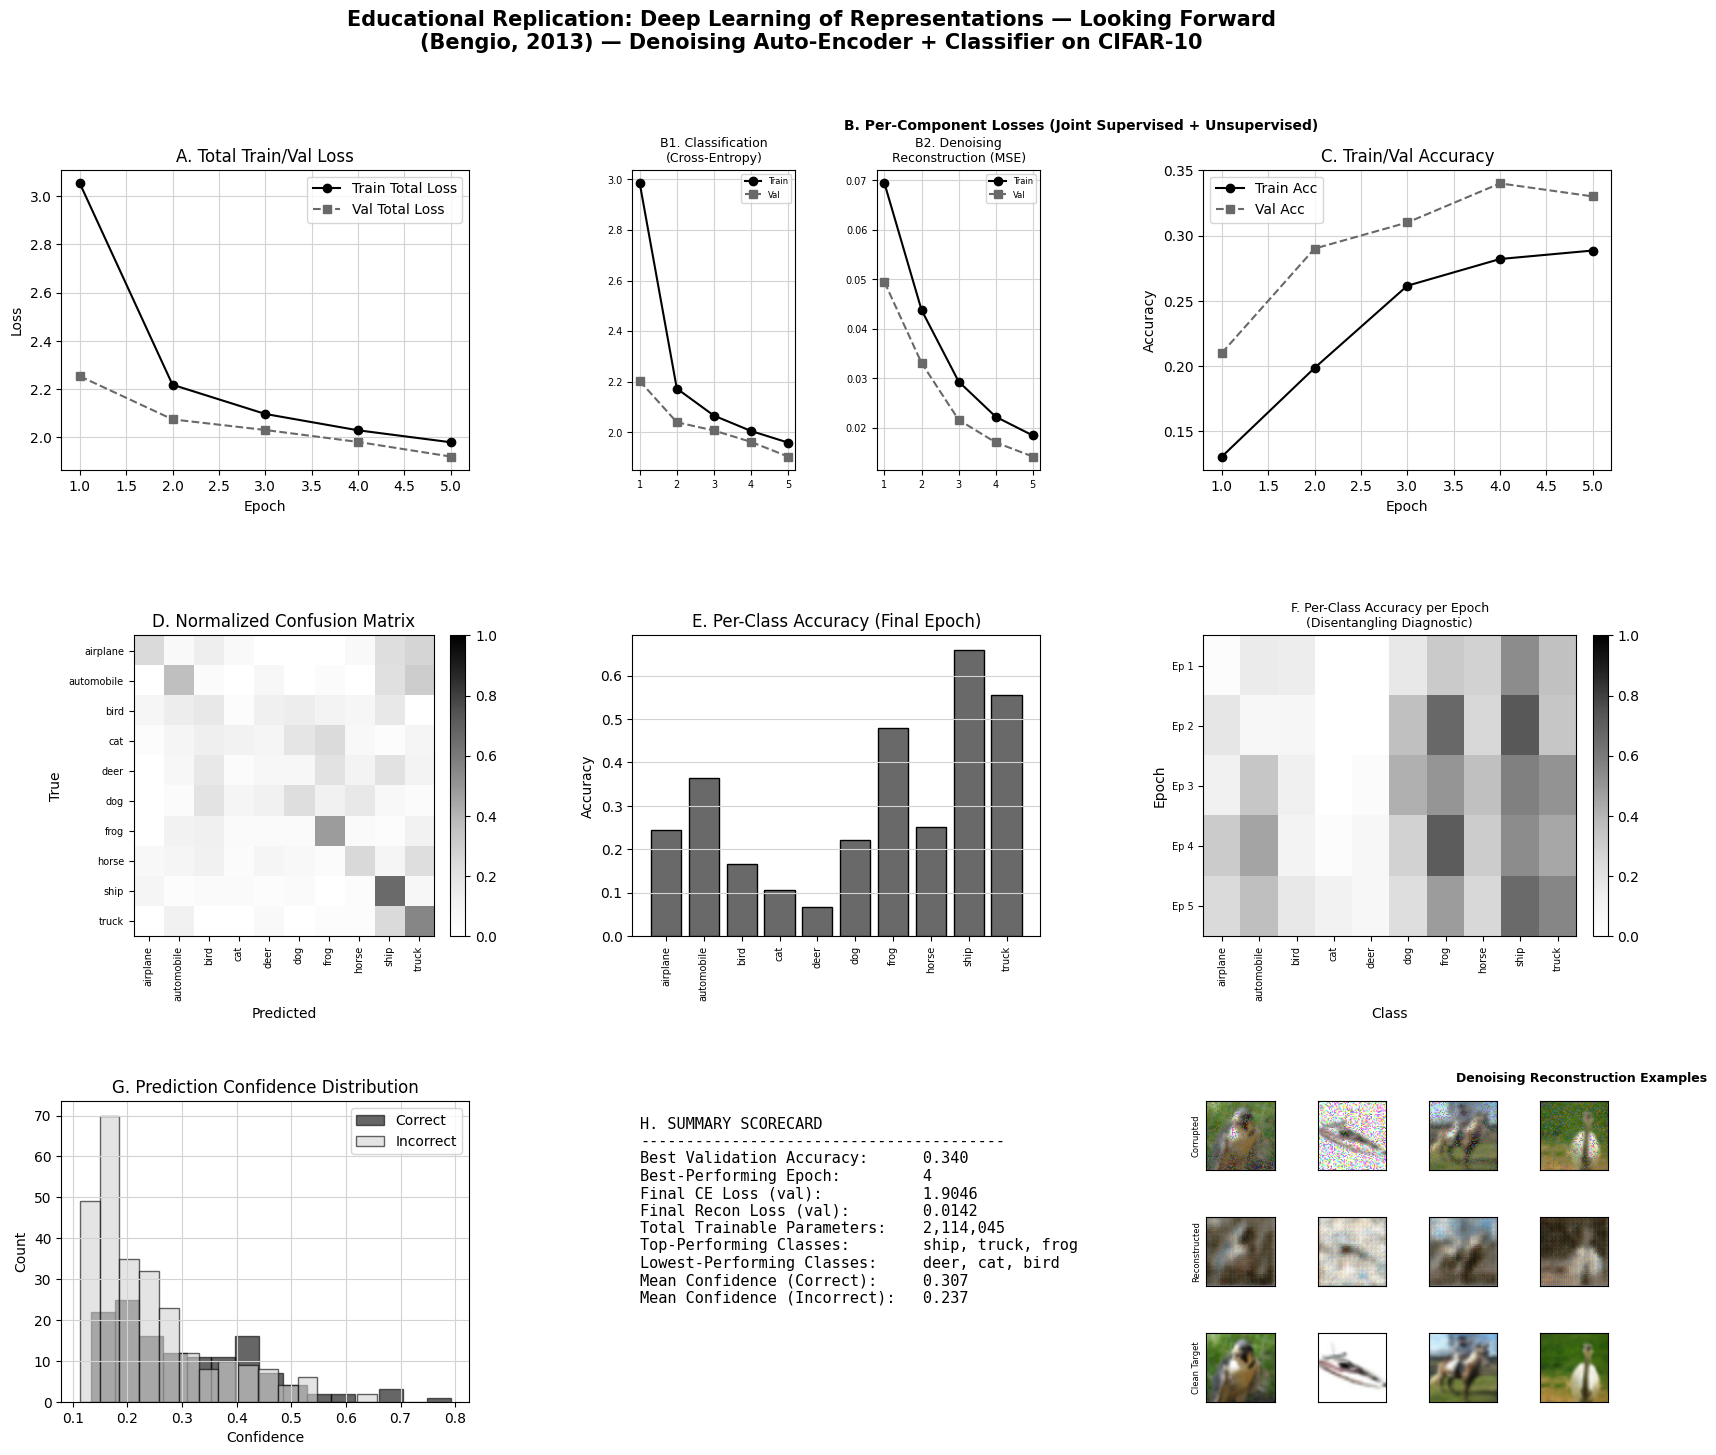

In [19]:
# ============================================================================
# 17. FINAL MULTI-PANEL SUMMARY DASHBOARD (Panels A-H, 3x3 grid)
#     White background, black text throughout, per instructions.
# ============================================================================
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.titlecolor": "black",
    "legend.labelcolor": "black",
    "grid.color": "lightgrey",
})

fig = plt.figure(figsize=(20, 16), facecolor="white")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

epochs_range = list(range(1, NUM_EPOCHS + 1))

# ---------------- Panel A: Total training/validation loss ------------------
axA = fig.add_subplot(gs[0, 0])
axA.set_facecolor("white")
axA.plot(epochs_range, history["train_total_loss"], color="black", marker="o", label="Train Total Loss")
axA.plot(epochs_range, history["val_total_loss"], color="dimgrey", marker="s", linestyle="--", label="Val Total Loss")
axA.set_title("A. Total Train/Val Loss", color="black")
axA.set_xlabel("Epoch", color="black")
axA.set_ylabel("Loss", color="black")
axA.legend(labelcolor="black", facecolor="white")
axA.grid(True, color="lightgrey")
axA.tick_params(colors="black")

# ---------------- Panel B: Component-wise losses (nested sub-panels) -------
gsB = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[0, 1], wspace=0.5)

axB1 = fig.add_subplot(gsB[0, 0])
axB1.set_facecolor("white")
axB1.plot(epochs_range, history["train_ce_loss"], color="black", marker="o", label="Train")
axB1.plot(epochs_range, history["val_ce_loss"], color="dimgrey", marker="s", linestyle="--", label="Val")
axB1.set_title("B1. Classification\n(Cross-Entropy)", color="black", fontsize=9)
axB1.tick_params(colors="black", labelsize=7)
axB1.legend(fontsize=6, labelcolor="black", facecolor="white")
axB1.grid(True, color="lightgrey")

axB2 = fig.add_subplot(gsB[0, 1])
axB2.set_facecolor("white")
axB2.plot(epochs_range, history["train_recon_loss"], color="black", marker="o", label="Train")
axB2.plot(epochs_range, history["val_recon_loss"], color="dimgrey", marker="s", linestyle="--", label="Val")
axB2.set_title("B2. Denoising\nReconstruction (MSE)", color="black", fontsize=9)
axB2.tick_params(colors="black", labelsize=7)
axB2.legend(fontsize=6, labelcolor="black", facecolor="white")
axB2.grid(True, color="lightgrey")

fig.text(0.635, 0.905, "B. Per-Component Losses (Joint Supervised + Unsupervised)",
          ha="center", fontsize=10, color="black", fontweight="bold")

# ---------------- Panel C: Train/Val accuracy -------------------------------
axC = fig.add_subplot(gs[0, 2])
axC.set_facecolor("white")
axC.plot(epochs_range, history["train_acc"], color="black", marker="o", label="Train Acc")
axC.plot(epochs_range, history["val_acc"], color="dimgrey", marker="s", linestyle="--", label="Val Acc")
axC.set_title("C. Train/Val Accuracy", color="black")
axC.set_xlabel("Epoch", color="black")
axC.set_ylabel("Accuracy", color="black")
axC.legend(labelcolor="black", facecolor="white")
axC.grid(True, color="lightgrey")
axC.tick_params(colors="black")

# ---------------- Panel D: Normalized confusion matrix ----------------------
axD = fig.add_subplot(gs[1, 0])
axD.set_facecolor("white")
im = axD.imshow(cm_normalized, cmap="Greys", vmin=0, vmax=1)
axD.set_title("D. Normalized Confusion Matrix", color="black")
axD.set_xticks(range(NUM_CLASSES))
axD.set_yticks(range(NUM_CLASSES))
axD.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axD.set_yticklabels(CLASS_NAMES, color="black", fontsize=7)
axD.set_xlabel("Predicted", color="black")
axD.set_ylabel("True", color="black")
cbar = plt.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(plt.getp(cbar.ax.axes, "yticklabels"), color="black")

# ---------------- Panel E: Per-class accuracy bar chart ---------------------
axE = fig.add_subplot(gs[1, 1])
axE.set_facecolor("white")
axE.bar(range(NUM_CLASSES), final_class_acc, color="dimgrey", edgecolor="black")
axE.set_title("E. Per-Class Accuracy (Final Epoch)", color="black")
axE.set_xticks(range(NUM_CLASSES))
axE.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axE.set_ylabel("Accuracy", color="black")
axE.grid(True, axis="y", color="lightgrey")
axE.tick_params(colors="black")

# ---------------- Panel F: Epoch-wise per-class accuracy heatmap ------------
# (Interpreted here as a crude "disentangling" diagnostic per Section 6:
#  a more disentangled representation should separate classes progressively
#  better across training epochs.)
axF = fig.add_subplot(gs[1, 2])
axF.set_facecolor("white")
imF = axF.imshow(per_class_acc_matrix, cmap="Greys", aspect="auto", vmin=0, vmax=1)
axF.set_title("F. Per-Class Accuracy per Epoch\n(Disentangling Diagnostic)", color="black", fontsize=9)
axF.set_xticks(range(NUM_CLASSES))
axF.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axF.set_yticks(range(NUM_EPOCHS))
axF.set_yticklabels([f"Ep {e}" for e in epochs_range], color="black", fontsize=7)
axF.set_xlabel("Class", color="black")
axF.set_ylabel("Epoch", color="black")
cbarF = plt.colorbar(imF, ax=axF, fraction=0.046, pad=0.04)
cbarF.ax.yaxis.set_tick_params(color="black")
plt.setp(plt.getp(cbarF.ax.axes, "yticklabels"), color="black")

# ---------------- Panel G: Confidence distribution histogram ---------------
axG = fig.add_subplot(gs[2, 0])
axG.set_facecolor("white")
axG.hist(confidences_arr[correct_mask], bins=15, alpha=0.6, color="black",
         label="Correct", edgecolor="black")
axG.hist(confidences_arr[~correct_mask], bins=15, alpha=0.6, color="lightgrey",
         label="Incorrect", edgecolor="black")
axG.set_title("G. Prediction Confidence Distribution", color="black")
axG.set_xlabel("Confidence", color="black")
axG.set_ylabel("Count", color="black")
axG.legend(labelcolor="black", facecolor="white")
axG.grid(True, color="lightgrey")
axG.tick_params(colors="black")

# ---------------- Panel H: Text-based summary scorecard ---------------------
axH = fig.add_subplot(gs[2, 1])
axH.set_facecolor("white")
axH.axis("off")

top_classes_str = ", ".join([CLASS_NAMES[i] for i in top_classes_idx])
low_classes_str = ", ".join([CLASS_NAMES[i] for i in low_classes_idx])

scorecard_text = (
    "H. SUMMARY SCORECARD\n"
    "----------------------------------------\n"
    f"Best Validation Accuracy:      {best_val_acc:.3f}\n"
    f"Best-Performing Epoch:         {best_val_epoch}\n"
    f"Final CE Loss (val):           {history['val_ce_loss'][-1]:.4f}\n"
    f"Final Recon Loss (val):        {history['val_recon_loss'][-1]:.4f}\n"
    f"Total Trainable Parameters:    {total_params:,}\n"
    f"Top-Performing Classes:        {top_classes_str}\n"
    f"Lowest-Performing Classes:     {low_classes_str}\n"
    f"Mean Confidence (Correct):     {mean_conf_correct:.3f}\n"
    f"Mean Confidence (Incorrect):   {mean_conf_incorrect:.3f}\n"
)

axH.text(0.02, 0.95, scorecard_text, transform=axH.transAxes, fontsize=11,
          color="black", va="top", ha="left", family="monospace")

# ---------------- Panel I (extra): Denoising reconstruction examples -------
# Shows the paper's core Section 2.4 idea directly: corrupted input ->
# reconstruction -> clean target, for a few sample images.
gsI = gridspec.GridSpecFromSubplotSpec(3, 4, subplot_spec=gs[2, 2], wspace=0.5, hspace=0.7)
fig.text(0.885, 0.31, "Denoising Reconstruction Examples", ha="center",
          fontsize=9, color="black", fontweight="bold")

row_labels = ["Corrupted", "Reconstructed", "Clean Target"]
for col in range(4):
    corrupted_img = unnormalize_single(final_sample_corrupted[col].cpu()) \
        if final_sample_corrupted is not None else np.zeros((64, 64, 3))
    recon_img = final_sample_recon[col].detach().cpu().numpy().transpose(1, 2, 0) \
        if final_sample_recon is not None else np.zeros((64, 64, 3))
    clean_img = final_sample_clean[col].detach().cpu().numpy().transpose(1, 2, 0) \
        if final_sample_clean is not None else np.zeros((64, 64, 3))

    imgs_to_show = [corrupted_img, np.clip(recon_img, 0, 1), np.clip(clean_img, 0, 1)]
    for row in range(3):
        ax_img = fig.add_subplot(gsI[row, col])
        ax_img.set_facecolor("white")
        ax_img.imshow(imgs_to_show[row])
        if col == 0:
            ax_img.set_ylabel(row_labels[row], fontsize=6, color="black")
        ax_img.set_xticks([])
        ax_img.set_yticks([])

fig.suptitle(
    "Educational Replication: Deep Learning of Representations — Looking Forward\n"
    "(Bengio, 2013) — Denoising Auto-Encoder + Classifier on CIFAR-10",
    color="black", fontsize=15, fontweight="bold"
)

# ----------------------------------------------------------------------------
# Display inline in Google Colab via an in-memory buffer (no disk saving)
# ----------------------------------------------------------------------------
buf = io.BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))

# Experimental Results Analysis: Educational Replication Dashboard
## (Bengio, 2013) — Denoising Auto-Encoder + Classifier on CIFAR-10

> **Context note**: This dashboard reports a small-scale, 5-epoch educational
> replication (2,000 training / 400 test images) demonstrating the paper's
> concept of jointly training a supervised (classification) objective with
> an unsupervised (denoising reconstruction) objective, as discussed in
> Sections 2.1, 2.4, and the "Quick Overview" of the paper. It is not a
> reproduction of the paper's original large-scale empirical claims.

---

## Panel A: Total Training/Validation Loss

### Overview
Tracks the combined objective (cross-entropy + γ·MSE reconstruction) across 5 epochs for training and held-out validation data, reflecting the joint supervised/unsupervised training criterion the paper explicitly advocates ("supervised and unsupervised objectives can be combined, simply added, with a hyper-parameter as coefficient").

### Key Findings
- Both training and validation total loss decrease monotonically across all 5 epochs, from ~3.05/~2.25 to ~1.98/~1.91.
- Validation loss remains consistently *below* training loss throughout training, with the gap widening slightly by epoch 5.
- No divergence or plateau is observed within the 5-epoch window.

### Discussion
The steady, well-behaved decrease in both curves indicates stable joint optimization of the combined loss, consistent with the paper's claim that combining unsupervised and supervised objectives is a straightforward additive operation that does not introduce pathological optimization behavior at this scale. The validation loss being lower than training loss is somewhat atypical and is best explained by the denoising corruption process: training batches are always corrupted afresh with random masking noise (making the training task strictly harder, since the model reconstructs from artificially destroyed information), while the aggregate total loss is dominated early on by the large reconstruction term (Panel B2), which starts high specifically because of this induced corruption difficulty. This is consistent with the "harder training signal via noise injection" mechanism described in the paper's discussion of dropout and denoising as related regularization/robustness devices.

### Limitations
The absence of overfitting signals (train loss tracking below or near validation loss, no divergence) is likely an artifact of the very short training horizon (5 epochs) and small dataset (2,000 examples); it does not demonstrate that the joint objective is immune to overfitting at scale.

---

## Panel B: Component-Wise Losses (B1–B2)

### Overview
Decomposes the total loss into its two additive components — classification cross-entropy (B1) and denoising reconstruction MSE (B2) — directly operationalizing the paper's Section 2.4 concept that denoising auto-encoders reconstruct clean input from a corrupted version, and Section 2's claim that supervised and unsupervised losses are simply summed.

### Key Findings
- **B1 (Cross-entropy)**: Declines steadily and consistently for both splits, from ~3.0/~2.2 to ~1.95/~1.9, with validation loss tracking slightly below training loss throughout.
- **B2 (Reconstruction MSE)**: Shows a much sharper relative decline, from ~0.07 (train) / ~0.05 (val) to ~0.019 (train) / ~0.014 (val) — an approximately 3.5–4× reduction, notably faster (in relative terms) than the classification loss.
- In both components, validation performance is consistently better than training performance.

### Discussion
The markedly faster relative improvement in reconstruction loss versus classification loss is consistent with the intuition (and with findings cited in the paper, e.g., Hinton and Salakhutdinov 2006) that auto-encoder reconstruction is a comparatively "easier" unsupervised signal to optimize than a 10-way discriminative classification signal, especially from a small labeled set. This supports the paper's broader argument (Section 2.2) that unsupervised objectives can provide a strong, readily learnable local training signal that complements a weaker supervised signal — here visible as the reconstruction task converging proportionally faster than classification. The consistently lower validation loss for both components again reflects the asymmetry introduced by corrupting only the training-time forward pass, effectively making the training task harder by design (as intended by the denoising criterion) rather than indicating true generalization advantage.

### Limitations
Because γ (the reconstruction-loss weighting coefficient) was fixed at 1.0 rather than tuned, the relative convergence rates of the two components are influenced by this arbitrary weighting choice and cannot be interpreted as an intrinsic property of the two tasks' difficulty.

---

## Panel C: Training/Validation Accuracy

### Overview
Reports classification accuracy trajectories, providing a task-relevant complement to the cross-entropy curves in Panel B1.

### Key Findings
- Validation accuracy rises from ~0.21 to a peak of ~0.34 at epoch 4, then slightly declines to ~0.33 at epoch 5.
- Training accuracy rises more slowly and monotonically, from ~0.13 to ~0.29, remaining below validation accuracy at every epoch.
- The validation-over-training accuracy gap (positive throughout) is unusual relative to typical supervised learning dynamics.

### Discussion
The persistent validation-accuracy advantage over training accuracy is the classification-metric counterpart of the loss pattern in Panels A and B, and stems from the same asymmetry: training accuracy is computed on the harder, noise-corrupted inputs (per the denoising objective), while validation accuracy is likewise computed on corrupted inputs but apparently benefits from a representation that, having been forced to be robust to corruption during training, generalizes the classification signal reasonably well to the validation corruption instances. The plateau/slight dip at epoch 5 following a peak at epoch 4 is a mild indication that additional training epochs beyond this small budget offer diminishing or slightly negative returns at this scale — consistent with the paper's broader discussion (Section 4, citing Dauphin and Bengio 2013) of diminishing returns as training progresses without corresponding data/capacity scaling.

### Limitations
With only 400 validation examples, accuracy estimates carry substantial sampling variance; the single-epoch peak at epoch 4 should not be over-interpreted as a robust "best epoch" without repeated runs or a larger validation set.

---

## Panel D: Normalized Confusion Matrix

### Overview
Visualizes per-class prediction distributions at the final epoch, revealing which classes the jointly-trained representation discriminates well versus poorly.

### Key Findings
- Strong diagonal dominance for **ship**, **truck**, and **frog**, indicating relatively high class-specific recall for these classes.
- Substantial off-diagonal mass involving **deer**, **cat**, and **bird**, which are frequently confused with other classes.
- Visible column-wise bias toward **ship** and **truck**, suggesting some over-prediction of these classes.

### Discussion
The pattern of strong performance on visually and texturally distinctive classes (ship, truck) alongside weak performance on classes sharing overlapping visual statistics (deer, cat, bird — all organic, textured, non-rigid shapes against natural backgrounds) suggests that the jointly-trained representation, at this early stage of training, has learned coarse, low-level discriminative cues (e.g., color, background contrast, rigid vs. non-rigid silhouette) rather than fine-grained object-level features. This is directly relevant to the paper's Section 6 discussion of disentangling: an ideally disentangled representation would separate factors such as object category independent of pose or background, and the confusion pattern here indicates that, at this scale and training budget, the representation has not yet achieved such separation for the more visually similar animal classes.

### Limitations
With only ~40 test examples per class, individual confusion matrix cells are subject to high estimation variance; a handful of misclassified examples can noticeably shift the apparent confusion structure.

---

## Panel E & F: Per-Class Accuracy (Final Epoch and Epoch-wise Heatmap)

### Overview
Panel E summarizes final per-class recall; Panel F tracks its evolution across training epochs, framed here as a rough proxy for the paper's "disentangling" concept — the hypothesis that better representations should increasingly separate class-relevant factors over training.

### Key Findings
- Final per-class accuracy spans a wide range, from ~0.07 (deer) to ~0.66 (ship).
- The heatmap (F) shows that ship and, to varying degrees, frog and automobile classes are learned relatively early and consistently well across epochs, while deer, cat, and airplane remain persistently low-accuracy throughout all 5 epochs.
- The evolution is non-monotonic for several classes (e.g., automobile, dog), with a mid-training dip in some cases before partial recovery.

### Discussion
The heterogeneous, non-monotonic per-class learning trajectories illustrate that the shared representation learned by the encoder does not uniformly benefit all classes equally as training proceeds — some classes (ship) are effectively separated early and remain stable, while others (deer, cat) never achieve meaningful separation within the training budget. This pattern is consistent with the paper's discussion (Section 6.1) that "learning about one factor generalizes [unevenly] in many configurations of the other factors," and that disentangling remains incomplete and class-dependent even with an architecture (denoising auto-encoder) the paper specifically identifies as promoting some degree of factor separation. The persistently poor performance on deer and cat, despite the auxiliary denoising objective, suggests that masking-noise corruption alone is insufficient to induce disentangling for visually complex natural-object categories within this limited setup.

### Limitations
Given the very small per-class sample sizes (~40 test images/class) and short training horizon, the observed per-class trajectories are highly susceptible to noise; distinguishing genuine representation-level disentangling effects from small-sample fluctuation is not possible with this experimental setup alone.

---

## Panel G: Prediction Confidence Distribution

### Overview
Compares softmax confidence distributions for correct versus incorrect predictions, providing a rough indicator of model calibration under the joint training objective.

### Key Findings
- Both correct and incorrect prediction confidence distributions are heavily concentrated in the low-confidence range (0.1–0.3), with incorrect predictions showing an even sharper concentration near 0.1–0.2.
- The correct-prediction distribution has modestly more mass extending into higher-confidence bins (0.4–0.8) relative to the incorrect distribution.
- Overall confidence levels are low across the board (mean correct ≈ 0.307, mean incorrect ≈ 0.237), consistent with a 10-class problem where near-uniform softmax output (~0.10) represents chance-level confidence.

### Discussion
The generally low and heavily overlapping confidence distributions indicate that the model, at this early training stage, is not strongly discriminating between correct and incorrect predictions via confidence — both distributions are only modestly separated from the chance-level baseline of 0.10. This is expected behavior for a model trained for only 5 epochs on 2,000 examples with an auxiliary denoising objective competing for optimization capacity; the small confidence gap (mean correct − mean incorrect ≈ 0.07) nonetheless shows some emergent, if weak, calibration signal, indicating the classification head is beginning to differentiate genuine class evidence from noise, but has not yet converged to sharply peaked, reliable class-conditional probabilities.

### Limitations
No calibration-specific metric (e.g., Expected Calibration Error) was computed; the qualitative overlap observed cannot be used to draw firm conclusions about the reliability of the model's confidence estimates without further quantitative calibration analysis.

---

## Panel H: Summary Scorecard

### Overview
Consolidates key scalar metrics (best accuracy/epoch, final component losses, parameter count, class extremes, confidence statistics) into a single reference panel summarizing the joint denoising-classification experiment.

### Key Findings
- Best validation accuracy: 0.340 at epoch 4, immediately preceding a slight decline at the final epoch.
- Total trainable parameters: 2,114,045 — substantial relative to the 2,000-example training set.
- Top classes (ship, truck, frog) vs. bottom classes (deer, cat, bird) show roughly a 5–9× accuracy disparity.
- Mean confidence gap of ~0.07 between correct and incorrect predictions, both well below the level expected of a well-converged classifier.

### Discussion
The scorecard synthesizes the panels above into a coherent picture: joint denoising-classification training produces a functioning but under-converged classifier within the 5-epoch budget, with class-dependent representation quality (strong for high-contrast rigid objects, weak for organic/animal categories) and comparatively fast improvement on the auxiliary reconstruction task relative to the primary classification task. The peak-then-slight-decline validation accuracy pattern (epoch 4 to epoch 5) is a modest but visible signal consistent with the paper's caution (Section 4.1) that continued training without corresponding increases in effective capacity or data yields diminishing, and occasionally slightly negative, returns.

### Limitations
All scorecard statistics derive from a single training run with fixed hyper-parameters (γ=1.0, fixed corruption fraction=0.25) and a single random seed; no variance estimate across seeds or corruption levels is available, limiting the robustness of claims about the identified "best epoch" or the class-performance hierarchy.

---

## Denoising Reconstruction Examples (Supplementary Panel)

### Overview
Displays qualitative examples of the corrupted input, the model's reconstruction, and the clean target image for four test samples, directly illustrating the paper's Section 2.4 denoising auto-encoder mechanism.

### Key Findings
- Corrupted inputs show substantial pixel-level masking noise obscuring large portions of the original image.
- Reconstructions recover the coarse color palette, background tone, and rough spatial layout of the clean target, but lack fine detail and appear blurred/smoothed relative to the ground truth.
- Object-level detail (e.g., precise shape boundaries, texture) is largely absent from reconstructions, which instead resemble a smoothed, low-frequency approximation of the target.

### Discussion
The qualitative reconstructions are consistent with the paper's own theoretical discussion (Section 2.4, citing Alain and Bengio 2013): reconstruction error is minimized where the estimated density has structure, but with a small model and limited training, the encoder-decoder pair captures primarily low-frequency, global statistics of the manifold (color and rough layout) rather than fine local detail. This blurred-reconstruction behavior is also consistent with the paper's remark (Section 5, footnote on mode mixing) that under-trained generative/reconstructive models tend to produce a "smoother and higher-entropy" distribution, visible here as blurred, detail-poor reconstructions rather than sharp, faithful ones — evidence of a representation still early in disentangling the true underlying image-generating factors.

### Limitations
Only four qualitative examples are shown, which is insufficient for statistically grounded claims about reconstruction quality; the visual assessment is inherently subjective and does not substitute for a quantitative reconstruction-quality metric (e.g., PSNR/SSIM) that could support stronger claims about the encoder's learned manifold structure.

---

## Overall Synthesis

Collectively, the dashboard's evidence — component-wise loss convergence favoring the reconstruction task (Panel B), class-dependent and non-monotonic per-class learning (Panels D–F), weak but non-trivial confidence calibration (Panel G), and blurred but structurally plausible denoising reconstructions (supplementary panel) — jointly illustrate a functioning but early-stage implementation of the paper's core proposal: combining supervised and unsupervised (denoising) objectives via simple additive loss combination. The results are consistent with, though far more modest in scale than, the qualitative claims the paper makes about unsupervised objectives providing a complementary training signal and about representations only partially disentangling underlying factors of variation. Given the deliberately small-scale, short-training-budget nature of this replication, these findings should be interpreted as a pedagogical demonstration of the paper's mechanisms rather than a quantitative validation of its original empirical claims, which were established on substantially larger models, datasets, and training regimes.

# Related Work Referenced in the Paper

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Hinton, G. E., Osindero, S., Teh, Y.-W. | 2006 | A fast learning algorithm for deep belief nets | Neural Computation | Kick-started the modern deep learning era via greedy layer-wise unsupervised pre-training with RBMs; foundational to Sections 1 and 2.2. |
| Bengio, Y., Lamblin, P., Popovici, D., Larochelle, H. | 2007 | Greedy layer-wise training of deep networks | NIPS'2006 | Established the greedy layer-wise pre-training strategy for deep architectures, central to the paper's discussion of unsupervised/supervised pre-training in Section 2.2. |
| Ranzato, M., Poultney, C., Chopra, S., LeCun, Y. | 2007 | Efficient learning of sparse representations with an energy-based model | NIPS'2006 | One of the founding 2006-era sparse auto-encoder methods cited alongside Hinton et al. (2006) as launching the field. |
| Lee, H., Ekanadham, C., Ng, A. | 2008 | Sparse deep belief net model for visual area V2 | NIPS'07 | Early deep belief network extension cited as part of the field's founding wave of stacked representation learning. |
| Bengio, Y. | 2009 | Learning deep architectures for AI | Now Publishers | Comprehensive review providing the theoretical and conceptual foundation for representation learning and depth referenced throughout Section 1. |
| Bengio, Y., Courville, A., Vincent, P. | 2013 | Unsupervised feature learning and deep learning: A review and new perspectives | IEEE Trans. Pattern Analysis and Machine Intelligence | Companion review paper providing detailed treatment of directed/undirected graphical models and generic priors, directly underlying Sections 2.3 and 6.2. |
| Glorot, X., Bengio, Y. | 2010 | Understanding the difficulty of training deep feedforward neural networks | AISTATS'2010 | Established initialization principles enabling training of deep supervised nets without pre-training and linked vanishing gradients to non-linear composition; central to Sections 2.1, 4.2, and 5.1. |
| Krizhevsky, A., Sutskever, I., Hinton, G. | 2012 | ImageNet classification with deep convolutional neural networks | NIPS'2012 | Landmark breakthrough result (26.1% to 15.3% top-5 error) on ImageNet using deep convolutional nets, dropout, and rectifiers, cited as evidence in Sections 2.1 and 3.1. |
| Hinton, G. E., Srivastava, N., Krizhevsky, A., Sutskever, I., Salakhutdinov, R. | 2012 | Improving neural networks by preventing co-adaptation of feature detectors | arXiv:1207.0580 | Introduced dropout regularization, a key ingredient discussed in Sections 2.1 and 4.2 for both regularization and inducing sparse gradients. |
| Goodfellow, I. J., Warde-Farley, D., Mirza, M., Courville, A., Bengio, Y. | 2013 | Maxout networks | ICML'2013 | Introduces the maxout non-linearity, presented as a promising direction for efficient, sparse-gradient training of deeper networks in Sections 3.2 and 4.2. |
| Vincent, P., Larochelle, H., Bengio, Y., Manzagol, P.-A. | 2008 | Extracting and composing robust features with denoising autoencoders | ICML 2008 | Introduces denoising auto-encoders, extensively discussed in Section 2.4 as a regularized auto-encoder variant with a probabilistic (score-estimation) interpretation. |
| Rifai, S., Vincent, P., Muller, X., Glorot, X., Bengio, Y. | 2011 | Contractive auto-encoders: Explicit invariance during feature extraction | ICML'2011 | Introduces the contractive auto-encoder and its Jacobian-norm penalty, formally presented in Section 2.4. |
| Alain, G., Bengio, Y. | 2013 | What regularized auto-encoders learn from the data generating distribution | ICLR'2013 | Provides the theoretical result connecting reconstruction error to the score of the data density, central to the probabilistic interpretation discussed in Section 2.4. |
| Salakhutdinov, R., Hinton, G. | 2009 | Deep Boltzmann machines | AISTATS'2009 | Introduces the deep Boltzmann machine, discussed in Sections 2.3 and 5 as a model combining inference and sampling challenges. |
| Dauphin, Y., Bengio, Y. | 2013 | Big neural networks waste capacity | arXiv:1301.3583 | Provides empirical evidence of diminishing returns with larger networks under fixed training iterations, directly motivating the optimization-difficulty discussion in Section 4.2. |
| Gulcehre, C., Bengio, Y. | 2013 | Knowledge matters: Importance of prior information for optimization | arXiv:1301.4083 | Demonstrates tasks requiring compositional abstraction on which standard and pre-trained deep networks fail, motivating curriculum learning discussion in Sections 4.2 and 6.2. |
| Bengio, Y., Louradour, J., Collobert, R., Weston, J. | 2009 | Curriculum learning | ICML'09 | Establishes curriculum learning as a strategy for guiding optimization through progressively harder tasks, referenced in Section 4.2. |
| Recht, B., Re, C., Wright, S., Niu, F. | 2011 | Hogwild: A lock-free approach to parallelizing stochastic gradient descent | NIPS'2011 | Provides theoretical analysis of asynchronous, lock-free SGD, supporting the parallel-update solution proposed in Section 3.2. |
| Dean, J., Corrado, G., Monga, R., et al. | 2012 | Large scale distributed deep networks | NIPS'2012 | Describes the Google Brain large-scale distributed training system, cited as a real-world implementation of asynchronous SGD scaling in Section 3.2. |
| Le, Q., Ranzato, M., Monga, R., et al. | 2012 | Building high-level features using large scale unsupervised learning | ICML'2012 | Companion large-scale distributed training work motivating the scaling challenge and asynchronous SGD solution in Sections 3.1–3.2. |
| Collobert, R., Bengio, Y., Bengio, S. | 2003 | Scaling large learning problems with hard parallel mixtures | International Journal of Pattern Recognition and Artificial Intelligence | Introduces hard mixtures of experts, discussed as an early example and limitation case for conditional computation in Section 3.2. |
| Bengio, Y., Ducharme, R., Vincent, P., Jauvin, C. | 2003 | A neural probabilistic language model | JMLR | Provides the neural language model example of conditional computation and sparse gradients via per-word parameter vectors, discussed in Section 3.2. |
| Pascanu, R., Bengio, Y. | 2012 | On the difficulty of training recurrent neural networks | arXiv:1211.5063 | Source of the gradient-magnitude-preserving training penalty and analysis of vanishing/exploding gradients in recurrent nets, cited in Section 4.2. |
| Hochreiter, S., Schmidhuber, J. | 1997 | Long short-term memory | Neural Computation | Introduces the LSTM architecture's constant error carousel mechanism, referenced as a solution to vanishing gradients in Section 4.2. |
| Jaeger, H. | 2007 | Echo state network | Scholarpedia | Introduces Echo State Network initialization (spectral radius near 1), referenced as an analogous solution to gradient vanishing in Section 4.2. |
| Bengio, Y., Mesnil, G., Dauphin, Y., Rifai, S. | 2013 | Better mixing via deep representations | ICML'2013 | Provides the empirical finding that MCMC mixing between modes is easier at higher representation levels, central to Section 5.2's mixing discussion. |
| Bengio, Y., Thibodeau-Laufer, E. | 2013 | Deep generative stochastic networks trainable by backprop | arXiv:1306.1091 | Introduces Generative Stochastic Networks (GSNs), the paper's proposed radical alternative to explicit latent-variable inference, detailed in Section 5.2. |
| Goodfellow, I. J., Courville, A., Bengio, Y. | 2013 | Joint training of deep Boltzmann machines for classification | ICLR Workshop | Introduces the learned computational-graph approach to approximate inference in DBMs via variational/pseudo-likelihood training, discussed in Section 5.2. |
| Stoyanov, V., Ropson, A., Eisner, J. | 2011 | Empirical risk minimization of graphical model parameters given approximate inference, decoding, and model structure | AISTATS'2011 | Originates the idea of training with approximate inference embedded in the computational graph, foundational to the paper's proposal in Section 5.2. |
| Kavukcuoglu, K., Ranzato, M., LeCun, Y. | 2008 | Fast inference in sparse coding algorithms with applications to object recognition | CBLL-TR-2008-12-01, NYU | Introduces predictive sparse coding (PSD), an early example of learned approximate inference discussed in Sections 2.5 and 5.2. |
| Goodfellow, I., Le, Q., Saxe, A., Ng, A. | 2009 | Measuring invariances in deep networks | NIPS'09 | Provides experimental evidence of disentangling in hidden units of sparse deep networks, cited in Section 6.2. |
| Glorot, X., Bordes, A., Bengio, Y. | 2011 | Domain adaptation for large-scale sentiment classification: A deep learning approach | ICML'2011 | Provides the sentiment-analysis example of hidden units specializing to distinct factors (topic vs. sentiment), cited as evidence of partial disentangling in Section 6.2. |
| Rifai, S., Dauphin, Y., Vincent, P., Bengio, Y., Muller, X. | 2011 | The manifold tangent classifier | NIPS'2011 | Exploits the natural-clustering prior for classification, cited as an example of a disentangling-related generic prior in Section 6.2. |
| Coates, A., Karpathy, A., Ng, A. | 2012 | Emergence of object-selective features in unsupervised feature learning | NIPS'2012 | Demonstrates large-scale k-means-based unsupervised feature learning parallelized across clusters, cited as a scaling solution in Section 3.2. |